In [1]:
!pip install netCDF4
!pip install pysolar

     |████████████████████████████████| 46 kB 4.0 MB/s 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pysolar.solar import *
import datetime

from matplotlib.pyplot import figure

from google.colab import files

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Dense, Dropout, Reshape, Flatten, \
    LSTM, GRU, Concatenate, BatchNormalization, TimeDistributed, RepeatVector
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

tf.test.gpu_device_name()
print(tf.__version__)

2.5.0


In [3]:
from datetime import datetime, timedelta
from netCDF4 import Dataset

from google.colab import drive, files

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
# Model Data
model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/model_data_new.npy') 

# Obs Data
obs_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/obs_data_new.npy') 

# Precomputed SZA
sza = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/sza_new.npy', allow_pickle=True)

#cloud cover from ERA5
cc = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/cc.npy')

#solar thermal radiation downwards data from ERA5
strd = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/strd.npy')


#total column supercooled liquid water data from ERA5
tcslw = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/tcslw.npy')

In [5]:
#Separate data for validation
obs_data_val = obs_data
model_data_val = model_data
sza_val = sza

obs_data_vis_val = obs_data_val[:,0]
obs_data_T_val = obs_data_val[:,2]
obs_data_Td_val = obs_data_val[:,3]
sza_val = np.repeat(np.expand_dims(sza, -1), 4, axis=1)

model_data_T_val = model_data_val[:,:,1]
model_data_Td_val = model_data_val[:,:,2]

bins = [-1, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
obs_data_vis_val = pd.cut(obs_data_vis_val, bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()

In [6]:
#Manual attempt to sampling
temp_list = [0,5,14,22,28,38,48,55,66,75,84,91,99,110,115,125,135,145,153,163,171,180,187,195]
print(len(temp_list))

num_list = []

for i in range(23) :

  if (i % 2) == 0 :

    num_list = num_list + ([True]*((temp_list[i+1]*1000-temp_list[i]*1000)))

  else :

    num_list = num_list + ([False]*((temp_list[i+1]*1000-temp_list[i]*1000)))

num_list = num_list + [False] * (197109 - len(num_list))

print(len(num_list))

max_vis = np.array(num_list)

24
197109


In [7]:
#"Winter" sample apparently
temp_list = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]
num_list = []

for i in range(197109) :

  qu = i//4500

  if qu in temp_list :

    num_list.append(True)

  else :

    num_list.append(False)

print(len(num_list))

max_vis = np.array(num_list)

197109


In [8]:
#October-February sample
temp_list = [0, 9]
for i in range(22) :

  prev = temp_list[i+1]

  if (i % 2) == 0 :

    temp_list.append(prev + 4)

  else :

    temp_list.append(prev + 8)

print(temp_list)

print(len(temp_list))

num_list = []

for i in range(23) :

  if (i % 2) == 0 :

    num_list = num_list + ([True]*((temp_list[i+1]*1464-temp_list[i]*1464)))

  else :

    num_list = num_list + ([False]*((temp_list[i+1]*1464-temp_list[i]*1464)))

num_list = num_list[:197109]

print(len(num_list))

max_vis = np.array(num_list)

print(max_vis)

[0, 9, 13, 21, 25, 33, 37, 45, 49, 57, 61, 69, 73, 81, 85, 93, 97, 105, 109, 117, 121, 129, 133, 141]
24
197109
[ True  True  True ...  True  True  True]


In [9]:
# Remove all the max visibility cases
#max_vis = obs_data[:,0] != obs_data[:,0].max()
obs_data = obs_data[max_vis,]
model_data = model_data[max_vis,]
sza = sza[max_vis]
cc_data =  cc[max_vis,]
tcslw_data = tcslw[max_vis,]

In [10]:
# Extract the individual features
obs_data_vis = obs_data[:,0]
obs_data_T = obs_data[:,2]
obs_data_Td = obs_data[:,3]

model_data_T = model_data[:,:,1]
model_data_Td = model_data[:,:,2]

sza = np.repeat(np.expand_dims(sza, -1), 4, axis=1)

obs_data_cc = np.repeat(np.expand_dims(cc_data, -1), 4, axis=1)
model_data_cc = np.repeat(np.expand_dims(cc_data, -1), 4, axis=1)

obs_data_tcslw = np.repeat(np.expand_dims(tcslw_data, -1), 4, axis=1)
model_data_tcslw = np.repeat(np.expand_dims(tcslw_data, -1), 4, axis=1)

In [11]:
# Bin the data
bins = [-1, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
obs_data_vis = pd.cut(obs_data_vis, bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()

In [12]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 12
future_target = 4

In [13]:
# Split into training data
TRAIN_SPLIT = np.int(0.8*len(obs_data_vis))
print(TRAIN_SPLIT)

106154


In [14]:
def multivariate_data_model(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)


def multivariate_data_obs(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [15]:
start_val = 200
end_val = 1000

In [16]:
STEP = 1

# This is the visibility (target) dataset
x_train_vis, y_train_vis = multivariate_data_obs(obs_data_vis, obs_data_vis, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_vis, y_val_vis = multivariate_data_obs(obs_data_vis, obs_data_vis,
                                             start_val, end_val, past_history,
                                             future_target, STEP)

# These are the auxiliary (T, Td, ws, wd, ceil) datasets
x_train_T_obs, _ = multivariate_data_obs(obs_data_T, obs_data_T, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T_obs, _ = multivariate_data_obs(obs_data_T, obs_data_T,
                                             start_val, end_val, past_history,
                                             future_target, STEP)

x_train_Td_obs, _ = multivariate_data_obs(obs_data_Td, obs_data_Td, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_Td_obs, _ = multivariate_data_obs(obs_data_Td, obs_data_Td,
                                             start_val, end_val, past_history,
                                             future_target, STEP)


x_train_T_model, _ = multivariate_data_model(model_data_T, model_data_T, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T_model, _ = multivariate_data_model(model_data_T, model_data_T,
                                             start_val, end_val, past_history,
                                             future_target, STEP)

x_train_Td_model, _ = multivariate_data_model(model_data_Td, model_data_Td, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_Td_model, _ = multivariate_data_model(model_data_Td, model_data_Td,
                                             start_val, end_val, past_history,
                                             future_target, STEP)


x_train_sza, _ = multivariate_data_model(sza, sza, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_sza, _ = multivariate_data_model(sza, sza,
                                             start_val, end_val, past_history,
                                             future_target, STEP)

x_train_cc_obs, _ = multivariate_data_obs(obs_data_cc, obs_data_cc, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)

x_val_cc_obs, _ = multivariate_data_obs(obs_data_cc, obs_data_cc,
                                             start_val, end_val, past_history,
                                            future_target, STEP)

x_train_cc_model, _ = multivariate_data_model(model_data_cc, model_data_cc, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)

x_val_cc_model, _ = multivariate_data_model(model_data_cc, model_data_cc,
                                             start_val, end_val, past_history,
                                             future_target, STEP)



x_train_tcslw_obs, _ = multivariate_data_obs(obs_data_tcslw, obs_data_tcslw, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)

x_val_tcslw_obs, _ = multivariate_data_obs(obs_data_tcslw, obs_data_tcslw,
                                             start_val, end_val, past_history,
                                            future_target, STEP)

x_train_tcslw_model, _ = multivariate_data_model(model_data_tcslw, model_data_tcslw, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)

x_val_tcslw_model, _ = multivariate_data_model(model_data_tcslw, model_data_tcslw,
                                             start_val, end_val, past_history,
                                             future_target, STEP)



(array([8.0000e+00, 9.4000e+01, 1.0500e+02, 5.6000e+01, 2.2200e+02,
        1.0010e+03, 2.7360e+03, 1.0192e+05]),
 array([0.   , 0.875, 1.75 , 2.625, 3.5  , 4.375, 5.25 , 6.125, 7.   ]),
 <a list of 8 Patch objects>)

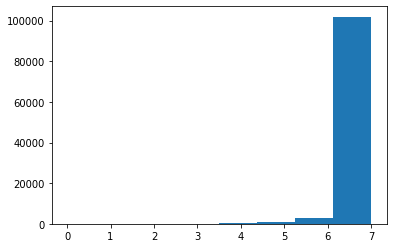

In [17]:
plt.hist(x_train_vis[:,0],bins=8)

In [18]:
# Using T-Td as feature
x_train_TTd_obs = x_train_T_obs-x_train_Td_obs
x_val_TTd_obs = x_val_T_obs-x_val_Td_obs

x_train_TTd_model = x_train_T_model-x_train_Td_model
x_val_TTd_model = x_val_T_model-x_val_Td_model

In [19]:
# Normalize the feature
TTd_max = np.max(x_train_TTd_obs)
TTd_min = np.min(x_train_TTd_obs)

T_max = np.max(x_train_T_obs) 
T_min = np.min(x_train_T_obs) 

sza_max = np.max(x_train_sza) 
sza_min = np.min(x_train_sza) 

cc_max = np.max(x_train_cc_obs)
cc_min = np.min(x_train_cc_model)

tcslw_max = np.max(x_train_tcslw_obs)
tcslw_min = np.min(x_train_tcslw_model)

x_train_TTd_obs = (x_train_TTd_obs - TTd_min)/(TTd_max - TTd_min)
x_val_TTd_obs = (x_val_TTd_obs - TTd_min)/(TTd_max - TTd_min)

x_train_TTd_model = (x_train_TTd_model - TTd_min)/(TTd_max - TTd_min)
x_val_TTd_model = (x_val_TTd_model - TTd_min)/(TTd_max - TTd_min)

x_train_T_obs = (x_train_T_obs - T_min)/(T_max - T_min)
x_val_T_obs = (x_val_T_obs - T_min)/(T_max - T_min)

x_train_T_model = (x_train_T_model - T_min)/(T_max - T_min)
x_val_T_model = (x_val_T_model - T_min)/(T_max - T_min)

x_train_sza = (x_train_sza - sza_min)/(sza_max - sza_min)
x_val_sza = (x_val_sza - sza_min)/(sza_max - sza_min)

x_train_cc_obs = (x_train_cc_obs - cc_min)/(cc_max - cc_min)
x_val_cc_obs = (x_val_cc_obs - cc_min)/(cc_max - cc_min)

x_train_cc_model = (x_train_cc_model - cc_min)/(cc_max - cc_min)
x_val_cc_model = (x_val_cc_model - cc_min)/(cc_max - cc_min)

x_train_tcslw_obs = (x_train_tcslw_obs - tcslw_min)/(tcslw_max - tcslw_min)
x_val_tcslw_obs = (x_val_tcslw_obs - tcslw_min)/(tcslw_max - tcslw_min)

x_train_tcslw_model = (x_train_tcslw_model - tcslw_min)/(tcslw_max - tcslw_min)
x_val_tcslw_model = (x_val_tcslw_model - tcslw_min)/(tcslw_max - tcslw_min)

In [20]:
# Concatenate the data
x_train_model = np.concatenate((x_train_T_model, x_train_TTd_model, x_train_sza, x_train_cc_model, x_train_tcslw_model), axis=2)

x_val_model = np.concatenate((x_val_T_model, x_val_TTd_model, x_val_sza, x_val_cc_model, x_val_tcslw_model), axis=2)

x_train_obs = np.stack((x_train_vis, x_train_TTd_obs), axis=2)
x_val_obs = np.stack((x_val_vis, x_val_TTd_obs), axis=2)

In [21]:
# Total number of model features
nr_features_model = x_train_model.shape[2]
nr_features_obs = x_train_obs.shape[2]

In [22]:
# Data shape
print ('Single window of past history : {}'.format(x_train_model[0].shape))
print ('Target visibility to predict : {}'.format(y_train_vis[0].shape))

Single window of past history : (16, 20)
Target visibility to predict : (4,)


In [23]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:])

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, 
                                                              y_pred_step_i)
    #tf.cast(tf.keras.losses.mse(y_true_step_i, tf.math.argmax(y_pred_step_i, axis=1)), tf.float32)
    
  return loss

In [24]:
def slice(x, length):
  return x[:,-length:,:]

In [25]:
input_shape_obs = (past_history, nr_features_obs,)
input_shape_model = (past_history+future_target, nr_features_model,)

in_obs = tf.keras.layers.Input(shape=input_shape_obs)
in_model = tf.keras.layers.Input(shape=input_shape_model)

b_obs = tf.keras.layers.LSTM(32, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(in_obs)
b_obs = tf.keras.layers.Lambda(slice, arguments={'length': 1})(b_obs)
b_obs = tf.keras.layers.Flatten()(b_obs)
b_obs = tf.keras.layers.RepeatVector(future_target)(b_obs)

b_model = tf.keras.layers.LSTM(32, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(in_model)
b_model = tf.keras.layers.Lambda(slice, arguments={'length': future_target})(b_model)

b = tf.keras.layers.Concatenate(axis=2)([b_obs, b_model])
# b = b_obs
b = tf.keras.layers.LSTM(16, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(b)
b = tf.keras.layers.LSTM(8, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(b)
out = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(8, activation='softmax'))(b)

model = tf.keras.models.Model([in_obs, in_model], out)
model.compile(optimizer='adam', loss=multi_layer_cross_entropy, metrics=['acc'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 12, 2)]      0                                            
__________________________________________________________________________________________________
lstm (LSTM)                     (None, 12, 32)       4480        input_1[0][0]                    
__________________________________________________________________________________________________
lambda (Lambda)                 (None, 1, 32)        0           lstm[0][0]                       
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 16, 20)]     0                                            
______________________________________________________________________________________________

In [26]:
multi_step_history = model.fit([x_train_obs, x_train_model], 
                               y_train_vis, batch_size=256,
                               validation_split=0.05, epochs=40,
                               callbacks=tf.keras.callbacks.EarlyStopping(patience=5))

Epoch 1/40
394/394 [==============================] - 16s 12ms/step - loss: 2.1678 - acc: 0.9502 - val_loss: 0.3303 - val_acc: 0.9989
Epoch 2/40
394/394 [==============================] - 4s 9ms/step - loss: 0.6387 - acc: 0.9600 - val_loss: 0.1254 - val_acc: 0.9989
Epoch 3/40
394/394 [==============================] - 4s 10ms/step - loss: 0.4694 - acc: 0.9662 - val_loss: 0.0843 - val_acc: 0.9989
Epoch 4/40
394/394 [==============================] - 4s 10ms/step - loss: 0.4201 - acc: 0.9692 - val_loss: 0.0692 - val_acc: 0.9988
Epoch 5/40
394/394 [==============================] - 4s 10ms/step - loss: 0.3960 - acc: 0.9711 - val_loss: 0.0714 - val_acc: 0.9985
Epoch 6/40
394/394 [==============================] - 4s 10ms/step - loss: 0.3855 - acc: 0.9716 - val_loss: 0.0665 - val_acc: 0.9985
Epoch 7/40
394/394 [==============================] - 4s 10ms/step - loss: 0.3761 - acc: 0.9721 - val_loss: 0.0643 - val_acc: 0.9985
Epoch 8/40
394/394 [==============================] - 4s 10ms/step - 

In [27]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

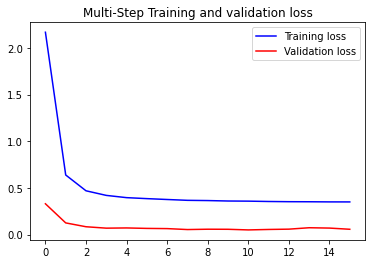

In [28]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'class')

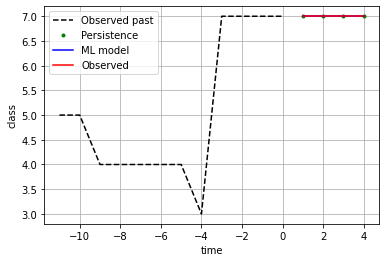

In [29]:
# Plot some results
ix = np.random.randint(0, len(x_val_vis))

vis = np.expand_dims(x_val_vis[ix,], axis=0)
true_vis = np.expand_dims(y_val_vis[ix,], axis=0)
data_obs = np.expand_dims(x_val_obs[ix,], axis=0)
data_model = np.expand_dims(x_val_model[ix,], axis=0)
# sza = np.expand_dims(x_val_sza[ix,], axis=0)

runs = 20
vis_prob = np.stack([model([data_obs, data_model], training=True) \
                     for sample in range(runs)])
vis_prob = np.argmax(vis_prob, axis=3)

vis_mean = np.round(vis_prob.mean(axis=0))
vis_std = vis_prob.std(axis=0)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target+1), x_val_vis[ix, past_history-1]*np.ones(future_target),'g.')

# ML prediction
plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b')
plt.fill_between(np.arange(1, future_target+1), vis_mean[0,]-vis_std[0,], vis_mean[0,]+vis_std[0,])

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'r')

plt.legend(['Observed past','Persistence','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

# for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [30]:
res = model([data_obs, data_model], training=True)[0,].numpy()
print(res.sum(axis=1))

[1.         0.99999994 1.         0.99999994]


In [31]:
# Proper verification
from sklearn.metrics import *

In [32]:
# Now verify the model
n_val = len(x_val_vis)
y_pers = np.zeros((n_val, future_target))
y_ml = np.zeros((n_val, future_target))

err_pers = np.zeros(n_val)
err_ml = np.zeros(n_val)

for i in range(n_val):

  # 1) Persistence error
  y_pers[i,] = x_val_vis[i, past_history-1]*np.ones(future_target)
  err_pers[i] = np.mean(np.square(y_pers[i,] - y_val_vis[i,]))

  # 3) ML model error
  vis = np.expand_dims(x_val_vis[i,], axis=0)
  true_vis = np.expand_dims(y_val_vis[i,], axis=0)
  data_obs = np.expand_dims(x_val_obs[i,], axis=0)
  data_model = np.expand_dims(x_val_model[i,], axis=0)

  vis_ml = model([data_obs, data_model])
  vis_ml = np.argmax(vis_ml, axis=2)
  
  err_ml[i] = np.mean(np.square(vis_ml[0,] - y_val_vis[i,]))
  y_ml[i,:] = vis_ml[0,]

print('Persistence error: {}'.format(np.sum(err_pers)))
print('ML model error: {}'.format(np.sum(err_ml)))

Persistence error: 320.5
ML model error: 324.5


In [33]:
nr_classes = 8

precision_pers = np.zeros((nr_classes,future_target))
recall_pers = np.zeros((nr_classes,future_target))
f1_pers = np.zeros((nr_classes,future_target))
balanced_acc_pers = np.zeros(future_target)

precision_ml = np.zeros((nr_classes,future_target))
recall_ml = np.zeros((nr_classes,future_target))
f1_ml = np.zeros((nr_classes,future_target))
balanced_acc_ml = np.zeros(future_target)

for i in range(future_target):
  precision_pers[:,i] = precision_score(y_val_vis[:,i], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  precision_ml[:,i] = precision_score(y_val_vis[:,i], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  recall_pers[:,i] = recall_score(y_val_vis[:,i], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  recall_ml[:,i] = recall_score(y_val_vis[:,i], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  f1_pers[:,i] = f1_score(y_val_vis[:,i], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  f1_ml[:,i] = f1_score(y_val_vis[:,i], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  
  balanced_acc_pers[i] = balanced_accuracy_score(y_val_vis[:,i], y_pers[:,i])
  balanced_acc_ml[i] = balanced_accuracy_score(y_val_vis[:,i], y_ml[:,i])

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1515: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  average, "true nor predicted", 'F-score is', len(true_sum)


In [34]:
def categorical_skill_scores(y_true, y_pred, labels=[0,1,2,3,4,5,6,7]):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=labels)
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [35]:
np.set_printoptions(precision=2)
for i in range(future_target):
  HSS, PSS = categorical_skill_scores(y_val_vis[:,i],y_ml[:,i])
  print('Prediction step {}:'.format(i+1))
  print('F1-score ML: {}'.format(f1_ml[:,i]))
  print('F1-score PE: {}'.format(f1_pers[:,i]))
  print('Balanced accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
  print('Balanced accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
  print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
  HSS, PSS = categorical_skill_scores(y_val_vis[:,i],y_pers[:,i])
  print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

Prediction step 1:
F1-score ML: [0.   0.   0.71 0.   0.   0.7  0.88 0.95]
F1-score PE: [0.   0.82 0.82 0.25 0.62 0.78 0.89 0.95]
Balanced accuracy ML: 0.52
Balanced accuracy PE: 0.73
Heidke skill score ML: 0.79062631733582
Peirce skill score ML: 0.7861613970195965
Heidke skill score PE: 0.8339818812713063
Peirce skill score PE: 0.834657731214974

Prediction step 2:
F1-score ML: [0.   0.   0.73 0.   0.   0.59 0.8  0.91]
F1-score PE: [0.   0.64 0.73 0.12 0.42 0.59 0.81 0.91]
Balanced accuracy ML: 0.49
Balanced accuracy PE: 0.6
Heidke skill score ML: 0.7017815270450994
Peirce skill score ML: 0.6983368872106219
Heidke skill score PE: 0.7137384412153235
Peirce skill score PE: 0.7149044015491172

Prediction step 3:
F1-score ML: [0.   0.   0.7  0.   0.   0.49 0.74 0.88]
F1-score PE: [0.   0.45 0.59 0.12 0.25 0.47 0.75 0.88]
Balanced accuracy ML: 0.45
Balanced accuracy PE: 0.5
Heidke skill score ML: 0.6239001295851989
Peirce skill score ML: 0.6196878329263877
Heidke skill score PE: 0.619345931

In [36]:
for i in range(future_target):
  print('Classification summary ML model at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_val_vis[:,i], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_val_vis[:,i], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('\n-----------------------------------------------------------')
  print('-----------------------------------------------------------\n')
  print('Classification summary Persistence at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_val_vis[:,i], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_val_vis[:,i], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))  
  print('\n')

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00        11
           2       0.55      1.00      0.71        22
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00        24
           5       0.62      0.80      0.70        69
           6       0.87      0.89      0.88       266
           7       0.96      0.95      0.95       388

   micro avg       0.87      0.87      0.87       788
   macro avg       0.37      0.46      0.41       788
weighted avg       0.83      0.87      0.85       788

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   0  10   0   0   0   1   0]
 [  0   0  22   0   0   0   0   0]
 [  0   0   4   0   0   4   0   0]
 [  0   0   3   0   0  18   3   0]
 [  0   0   0   0   0  55  14   0]
 [  0   0   0   0   0  12 237  17]
 [  0   0   1   0   0   0  17 37

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [37]:
'''
TRUE VAL

Prediction step 1:
F1-score ML: [0.   0.82 0.82 0.29 0.64 0.77 0.89 0.95]
F1-score PE: [0.   0.82 0.82 0.25 0.62 0.77 0.89 0.95]
Balanced accuracy ML: 0.74
Balanced accuracy PE: 0.73
Heidke skill score ML: 0.8329178993990195
Peirce skill score ML: 0.8325904371735222
Heidke skill score PE: 0.8309952972168939
Peirce skill score PE: 0.8309952972168939

Prediction step 2:
F1-score ML: [0.   0.67 0.73 0.2  0.39 0.67 0.81 0.91]
F1-score PE: [0.   0.64 0.73 0.12 0.42 0.59 0.81 0.91]
Balanced accuracy ML: 0.63
Balanced accuracy PE: 0.6
Heidke skill score ML: 0.7266420016116276
Peirce skill score ML: 0.729369606699087
Heidke skill score PE: 0.7097095693372532
Peirce skill score PE: 0.7097095693372532

Prediction step 3:
F1-score ML: [0.   0.58 0.67 0.   0.19 0.58 0.76 0.88]
F1-score PE: [0.   0.45 0.59 0.12 0.25 0.46 0.75 0.88]
Balanced accuracy ML: 0.54
Balanced accuracy PE: 0.5
Heidke skill score ML: 0.6461046521818605
Peirce skill score ML: 0.6461418647862212
Heidke skill score PE: 0.6142716195303227
Peirce skill score PE: 0.6142716195303227

Prediction step 4:
F1-score ML: [0.   0.5  0.68 0.   0.11 0.52 0.73 0.86]
F1-score PE: [0.   0.27 0.45 0.   0.17 0.36 0.7  0.84]
Balanced accuracy ML: 0.49
Balanced accuracy PE: 0.4
Heidke skill score ML: 0.602349298852668
Peirce skill score ML: 0.5963369376317805
Heidke skill score PE: 0.5347399946912139
Peirce skill score PE: 0.5347399946912139

'''

'\nTRUE VAL\n\nPrediction step 1:\nF1-score ML: [0.   0.82 0.82 0.29 0.64 0.77 0.89 0.95]\nF1-score PE: [0.   0.82 0.82 0.25 0.62 0.77 0.89 0.95]\nBalanced accuracy ML: 0.74\nBalanced accuracy PE: 0.73\nHeidke skill score ML: 0.8329178993990195\nPeirce skill score ML: 0.8325904371735222\nHeidke skill score PE: 0.8309952972168939\nPeirce skill score PE: 0.8309952972168939\n\nPrediction step 2:\nF1-score ML: [0.   0.67 0.73 0.2  0.39 0.67 0.81 0.91]\nF1-score PE: [0.   0.64 0.73 0.12 0.42 0.59 0.81 0.91]\nBalanced accuracy ML: 0.63\nBalanced accuracy PE: 0.6\nHeidke skill score ML: 0.7266420016116276\nPeirce skill score ML: 0.729369606699087\nHeidke skill score PE: 0.7097095693372532\nPeirce skill score PE: 0.7097095693372532\n\nPrediction step 3:\nF1-score ML: [0.   0.58 0.67 0.   0.19 0.58 0.76 0.88]\nF1-score PE: [0.   0.45 0.59 0.12 0.25 0.46 0.75 0.88]\nBalanced accuracy ML: 0.54\nBalanced accuracy PE: 0.5\nHeidke skill score ML: 0.6461046521818605\nPeirce skill score ML: 0.64614186

In [38]:
'''
NO MAX VIS VAL:

Prediction step 1:
F1-score ML: [0.   0.82 0.82 0.15 0.63 0.78 0.85 0.92]
F1-score PE: [0.   0.82 0.82 0.25 0.57 0.77 0.85 0.92]
Balanced accuracy ML: 0.71
Balanced accuracy PE: 0.71
Heidke skill score ML: 0.7828816363925322
Peirce skill score ML: 0.7824317821888562
Heidke skill score PE: 0.78115174930042
Peirce skill score PE: 0.78115174930042

Prediction step 2:
F1-score ML: [0.   0.61 0.71 0.2  0.35 0.63 0.75 0.86]
F1-score PE: [0.   0.64 0.73 0.12 0.36 0.58 0.74 0.85]
Balanced accuracy ML: 0.58
Balanced accuracy PE: 0.57
Heidke skill score ML: 0.6374557222712562
Peirce skill score ML: 0.6326328968452328
Heidke skill score PE: 0.6123789457948117
Peirce skill score PE: 0.6123789457948117

Prediction step 3:
F1-score ML: [0.   0.54 0.64 0.   0.14 0.5  0.7  0.8 ]
F1-score PE: [0.   0.45 0.59 0.12 0.25 0.46 0.66 0.79]
Balanced accuracy ML: 0.48
Balanced accuracy PE: 0.47
Heidke skill score ML: 0.5371958632404616
Peirce skill score ML: 0.5274272740438295
Heidke skill score PE: 0.4936815894831751
Peirce skill score PE: 0.4936815894831751

Prediction step 4:
F1-score ML: [0.   0.48 0.68 0.   0.05 0.28 0.64 0.75]
F1-score PE: [0.   0.27 0.45 0.   0.18 0.38 0.61 0.74]
Balanced accuracy ML: 0.42
Balanced accuracy PE: 0.38
Heidke skill score ML: 0.431647501583273
Peirce skill score ML: 0.4158955415799687
Heidke skill score PE: 0.40810379437422145
Peirce skill score PE: 0.4082879386528884

'''

'\nNO MAX VIS VAL:\n\nPrediction step 1:\nF1-score ML: [0.   0.82 0.82 0.15 0.63 0.78 0.85 0.92]\nF1-score PE: [0.   0.82 0.82 0.25 0.57 0.77 0.85 0.92]\nBalanced accuracy ML: 0.71\nBalanced accuracy PE: 0.71\nHeidke skill score ML: 0.7828816363925322\nPeirce skill score ML: 0.7824317821888562\nHeidke skill score PE: 0.78115174930042\nPeirce skill score PE: 0.78115174930042\n\nPrediction step 2:\nF1-score ML: [0.   0.61 0.71 0.2  0.35 0.63 0.75 0.86]\nF1-score PE: [0.   0.64 0.73 0.12 0.36 0.58 0.74 0.85]\nBalanced accuracy ML: 0.58\nBalanced accuracy PE: 0.57\nHeidke skill score ML: 0.6374557222712562\nPeirce skill score ML: 0.6326328968452328\nHeidke skill score PE: 0.6123789457948117\nPeirce skill score PE: 0.6123789457948117\n\nPrediction step 3:\nF1-score ML: [0.   0.54 0.64 0.   0.14 0.5  0.7  0.8 ]\nF1-score PE: [0.   0.45 0.59 0.12 0.25 0.46 0.66 0.79]\nBalanced accuracy ML: 0.48\nBalanced accuracy PE: 0.47\nHeidke skill score ML: 0.5371958632404616\nPeirce skill score ML: 0.52

In [39]:
'''
TRUE VAL

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.82      0.82      0.82        11
           2       0.82      0.82      0.82        22
           3       0.33      0.25      0.29         8
           4       0.62      0.67      0.64        24
           5       0.77      0.77      0.77        70
           6       0.89      0.89      0.89       267
           7       0.95      0.95      0.95       392

   micro avg       0.89      0.89      0.89       794
   macro avg       0.65      0.65      0.65       794
weighted avg       0.89      0.89      0.89       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   9   0   1   0   0   1   0]
 [  0   2  18   2   0   0   0   0]
 [  0   0   3   2   3   0   0   0]
 [  0   0   1   1  16   4   2   0]
 [  0   0   0   0   5  54  10   1]
 [  0   0   0   0   1  11 237  18]
 [  0   0   0   0   1   1  16 374]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 1:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.82      0.82      0.82        11
           2       0.82      0.82      0.82        22
           3       0.25      0.25      0.25         8
           4       0.62      0.62      0.62        24
           5       0.77      0.77      0.77        70
           6       0.89      0.89      0.89       267
           7       0.95      0.95      0.95       392

   micro avg       0.89      0.89      0.89       794
   macro avg       0.64      0.64      0.64       794
weighted avg       0.89      0.89      0.89       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   9   0   1   0   0   1   0]
 [  0   2  18   2   0   0   0   0]
 [  0   0   3   2   3   0   0   0]
 [  0   0   1   2  15   4   2   0]
 [  0   0   0   0   5  54  11   0]
 [  0   0   0   0   1  11 237  18]
 [  0   0   0   1   0   1  16 374]]


Classification summary ML model at forecast hour 2:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.62      0.73      0.67        11
           2       0.73      0.73      0.73        22
           3       0.50      0.12      0.20         8
           4       0.41      0.38      0.39        24
           5       0.60      0.74      0.67        70
           6       0.83      0.79      0.81       267
           7       0.91      0.91      0.91       392

   micro avg       0.83      0.83      0.83       794
   macro avg       0.57      0.55      0.55       794
weighted avg       0.83      0.83      0.82       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   8   1   0   0   0   2   0]
 [  0   5  16   1   0   0   0   0]
 [  0   0   2   1   5   0   0   0]
 [  0   0   2   0   9  10   3   0]
 [  0   0   1   0   5  52  10   2]
 [  0   0   0   0   1  21 212  33]
 [  0   0   0   0   2   3  29 358]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 2:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.64      0.64      0.64        11
           2       0.73      0.73      0.73        22
           3       0.12      0.12      0.12         8
           4       0.42      0.42      0.42        24
           5       0.59      0.59      0.59        70
           6       0.81      0.81      0.81       267
           7       0.91      0.91      0.91       392

   micro avg       0.82      0.82      0.82       794
   macro avg       0.53      0.53      0.53       794
weighted avg       0.82      0.82      0.82       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   7   1   1   0   0   2   0]
 [  0   4  16   2   0   0   0   0]
 [  0   0   2   1   5   0   0   0]
 [  0   0   2   1  10   8   3   0]
 [  0   0   1   2   7  41  18   1]
 [  0   0   0   0   1  18 215  33]
 [  0   0   0   1   1   3  29 358]]


Classification summary ML model at forecast hour 3:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.54      0.64      0.58        11
           2       0.65      0.68      0.67        22
           3       0.00      0.00      0.00         8
           4       0.22      0.17      0.19        24
           5       0.52      0.66      0.58        70
           6       0.78      0.74      0.76       267
           7       0.87      0.88      0.88       392

   micro avg       0.78      0.78      0.78       794
   macro avg       0.45      0.47      0.46       794
weighted avg       0.77      0.78      0.77       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   7   1   0   0   1   2   0]
 [  0   6  15   0   1   0   0   0]
 [  0   0   3   0   4   1   0   0]
 [  0   0   2   0   4  14   3   1]
 [  0   0   2   0   5  46  12   5]
 [  0   0   0   0   0  23 198  46]
 [  0   0   0   0   4   3  39 346]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 3:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.45      0.45      0.45        11
           2       0.59      0.59      0.59        22
           3       0.12      0.12      0.12         8
           4       0.25      0.25      0.25        24
           5       0.46      0.46      0.46        70
           6       0.75      0.75      0.75       267
           7       0.88      0.88      0.88       392

   micro avg       0.76      0.76      0.76       794
   macro avg       0.44      0.44      0.44       794
weighted avg       0.76      0.76      0.76       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   5   2   1   0   1   2   0]
 [  0   6  13   2   1   0   0   0]
 [  0   0   2   1   5   0   0   0]
 [  0   0   2   0   6  12   3   1]
 [  0   0   3   3   6  32  22   4]
 [  0   0   0   0   3  20 200  44]
 [  0   0   0   1   3   5  40 343]]


Classification summary ML model at forecast hour 4:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.46      0.55      0.50        11
           2       0.68      0.68      0.68        22
           3       0.00      0.00      0.00         8
           4       0.14      0.08      0.11        24
           5       0.49      0.54      0.52        70
           6       0.74      0.73      0.73       267
           7       0.84      0.87      0.86       392

   micro avg       0.75      0.75      0.75       794
   macro avg       0.42      0.43      0.42       794
weighted avg       0.74      0.75      0.74       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   6   1   0   0   2   2   0]
 [  0   6  15   0   1   0   0   0]
 [  0   0   2   0   3   3   0   0]
 [  0   1   1   0   2  14   5   1]
 [  0   0   3   0   4  38  17   8]
 [  0   0   0   0   0  18 195  54]
 [  0   0   0   0   4   2  46 340]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 4:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.27      0.27      0.27        11
           2       0.45      0.45      0.45        22
           3       0.00      0.00      0.00         8
           4       0.17      0.17      0.17        24
           5       0.36      0.36      0.36        70
           6       0.70      0.70      0.70       267
           7       0.84      0.84      0.84       392

   micro avg       0.71      0.71      0.71       794
   macro avg       0.35      0.35      0.35       794
weighted avg       0.71      0.71      0.71       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   3   3   1   0   2   2   0]
 [  0   8  10   3   1   0   0   0]
 [  0   0   2   0   4   2   0   0]
 [  0   0   2   0   4  13   4   1]
 [  0   0   4   1   8  25  24   8]
 [  0   0   1   2   3  22 187  52]
 [  0   0   0   1   4   6  50 331]]

'''

'\nTRUE VAL\n\nClassification summary ML model at forecast hour 1:\n\n              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00         0\n           1       0.82      0.82      0.82        11\n           2       0.82      0.82      0.82        22\n           3       0.33      0.25      0.29         8\n           4       0.62      0.67      0.64        24\n           5       0.77      0.77      0.77        70\n           6       0.89      0.89      0.89       267\n           7       0.95      0.95      0.95       392\n\n   micro avg       0.89      0.89      0.89       794\n   macro avg       0.65      0.65      0.65       794\nweighted avg       0.89      0.89      0.89       794\n\nConfusion matrix:\n\n[[  0   0   0   0   0   0   0   0]\n [  0   9   0   1   0   0   1   0]\n [  0   2  18   2   0   0   0   0]\n [  0   0   3   2   3   0   0   0]\n [  0   0   1   1  16   4   2   0]\n [  0   0   0   0   5  54  10   1]\n [  0   0   0   0   1  11 2

In [40]:
'''
NO MAX VIS VAL:

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.82      0.82      0.82        11
           2       0.82      0.82      0.82        22
           3       0.20      0.12      0.15         8
           4       0.62      0.64      0.63        28
           5       0.77      0.78      0.78       111
           6       0.85      0.85      0.85       302
           7       0.92      0.92      0.92       312

   micro avg       0.85      0.85      0.85       794
   macro avg       0.62      0.62      0.62       794
weighted avg       0.85      0.85      0.85       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   9   0   1   0   0   1   0]
 [  0   2  18   2   0   0   0   0]
 [  0   0   3   1   4   0   0   0]
 [  0   0   1   0  18   7   2   0]
 [  0   0   0   0   6  87  18   0]
 [  0   0   0   0   1  19 256  26]
 [  0   0   0   1   0   0  23 288]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 1:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.82      0.82      0.82        11
           2       0.82      0.82      0.82        22
           3       0.25      0.25      0.25         8
           4       0.57      0.57      0.57        28
           5       0.77      0.77      0.77       111
           6       0.85      0.85      0.85       302
           7       0.92      0.92      0.92       312

   micro avg       0.85      0.85      0.85       794
   macro avg       0.63      0.63      0.63       794
weighted avg       0.85      0.85      0.85       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   9   0   1   0   0   1   0]
 [  0   2  18   2   0   0   0   0]
 [  0   0   3   2   3   0   0   0]
 [  0   0   1   2  16   7   2   0]
 [  0   0   0   0   8  85  18   0]
 [  0   0   0   0   1  19 258  24]
 [  0   0   0   1   0   0  23 288]]


Classification summary ML model at forecast hour 2:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.58      0.64      0.61        11
           2       0.70      0.73      0.71        22
           3       0.50      0.12      0.20         8
           4       0.44      0.29      0.35        28
           5       0.62      0.64      0.63       111
           6       0.74      0.75      0.75       302
           7       0.85      0.87      0.86       312

   micro avg       0.76      0.76      0.76       794
   macro avg       0.55      0.50      0.51       794
weighted avg       0.75      0.76      0.75       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   7   2   0   0   0   2   0]
 [  0   5  16   1   0   0   0   0]
 [  0   0   2   1   4   1   0   0]
 [  0   0   2   0   8  15   3   0]
 [  0   0   1   0   4  71  34   1]
 [  0   0   0   0   0  27 227  48]
 [  0   0   0   0   2   1  39 270]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 2:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.64      0.64      0.64        11
           2       0.73      0.73      0.73        22
           3       0.12      0.12      0.12         8
           4       0.36      0.36      0.36        28
           5       0.58      0.58      0.58       111
           6       0.74      0.74      0.74       302
           7       0.85      0.85      0.85       312

   micro avg       0.74      0.74      0.74       794
   macro avg       0.50      0.50      0.50       794
weighted avg       0.74      0.74      0.74       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   7   1   1   0   0   2   0]
 [  0   4  16   2   0   0   0   0]
 [  0   0   2   1   5   0   0   0]
 [  0   0   2   1  10  12   3   0]
 [  0   0   1   2  11  64  32   1]
 [  0   0   0   0   1  33 222  46]
 [  0   0   0   1   1   2  43 265]]


Classification summary ML model at forecast hour 3:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.47      0.64      0.54        11
           2       0.64      0.64      0.64        22
           3       0.00      0.00      0.00         8
           4       0.20      0.11      0.14        28
           5       0.54      0.47      0.50       111
           6       0.68      0.72      0.70       302
           7       0.78      0.82      0.80       312

   micro avg       0.69      0.69      0.69       794
   macro avg       0.41      0.42      0.41       794
weighted avg       0.67      0.69      0.68       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   7   1   0   0   1   2   0]
 [  0   7  14   0   1   0   0   0]
 [  0   1   2   0   3   2   0   0]
 [  0   0   2   0   3  17   5   1]
 [  0   0   3   0   6  52  44   6]
 [  0   0   0   0   0  21 216  65]
 [  0   0   0   0   2   3  50 257]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 3:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.45      0.45      0.45        11
           2       0.59      0.59      0.59        22
           3       0.12      0.12      0.12         8
           4       0.25      0.25      0.25        28
           5       0.46      0.46      0.46       111
           6       0.66      0.66      0.66       302
           7       0.79      0.79      0.79       312

   micro avg       0.66      0.66      0.66       794
   macro avg       0.42      0.42      0.42       794
weighted avg       0.66      0.66      0.66       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   5   2   1   0   1   2   0]
 [  0   6  13   2   1   0   0   0]
 [  0   0   2   1   5   0   0   0]
 [  0   0   2   0   7  15   3   1]
 [  0   0   3   3   9  51  41   4]
 [  0   0   0   0   3  40 198  61]
 [  0   0   0   1   3   4  58 246]]


Classification summary ML model at forecast hour 4:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.43      0.55      0.48        11
           2       0.68      0.68      0.68        22
           3       0.00      0.00      0.00         8
           4       0.10      0.04      0.05        28
           5       0.38      0.22      0.28       110
           6       0.60      0.68      0.64       303
           7       0.72      0.79      0.75       312

   micro avg       0.63      0.63      0.63       794
   macro avg       0.36      0.37      0.36       794
weighted avg       0.59      0.63      0.61       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   6   1   0   0   2   2   0]
 [  0   6  15   0   1   0   0   0]
 [  0   1   1   0   3   2   1   0]
 [  0   1   1   0   1  17   7   1]
 [  0   0   4   0   2  24  66  14]
 [  0   0   0   0   0  16 205  82]
 [  0   0   0   0   3   3  58 248]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 4:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.27      0.27      0.27        11
           2       0.45      0.45      0.45        22
           3       0.00      0.00      0.00         8
           4       0.18      0.18      0.18        28
           5       0.38      0.38      0.38       110
           6       0.61      0.61      0.61       303
           7       0.74      0.74      0.74       312

   micro avg       0.60      0.60      0.60       794
   macro avg       0.33      0.33      0.33       794
weighted avg       0.60      0.60      0.60       794

Confusion matrix:

[[  0   0   0   0   0   0   0   0]
 [  0   3   3   1   0   2   2   0]
 [  0   8  10   3   1   0   0   0]
 [  0   0   2   0   4   2   0   0]
 [  0   0   2   0   5  15   5   1]
 [  0   0   4   1  11  42  44   8]
 [  0   0   1   2   3  41 184  72]
 [  0   0   0   1   4   9  67 231]]

'''

'\nNO MAX VIS VAL:\n\nClassification summary ML model at forecast hour 1:\n\n              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00         0\n           1       0.82      0.82      0.82        11\n           2       0.82      0.82      0.82        22\n           3       0.20      0.12      0.15         8\n           4       0.62      0.64      0.63        28\n           5       0.77      0.78      0.78       111\n           6       0.85      0.85      0.85       302\n           7       0.92      0.92      0.92       312\n\n   micro avg       0.85      0.85      0.85       794\n   macro avg       0.62      0.62      0.62       794\nweighted avg       0.85      0.85      0.85       794\n\nConfusion matrix:\n\n[[  0   0   0   0   0   0   0   0]\n [  0   9   0   1   0   0   1   0]\n [  0   2  18   2   0   0   0   0]\n [  0   0   3   1   4   0   0   0]\n [  0   0   1   0  18   7   2   0]\n [  0   0   0   0   6  87  18   0]\n [  0   0   0   0   